# TCGA PANCAN RNA-seq — Exploratory Data Analysis

Sanity checks before wiring the dataset into the Flower client. Four questions:

1. **Class balance** across the 5 tumor types (BRCA, KIRC, LUAD, PRAD, COAD).
2. **Missing values** and **constant / near-zero-variance genes** worth dropping.
3. **Distributional fingerprint** — are these raw HTSeq counts, or already log/RSEM normalized?
4. **Duplicate / near-duplicate samples** (bad for federated splits — leakage between clients).

Findings summarized at the bottom.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../../gene+expression+cancer+rna+seq/TCGA-PANCAN-HiSeq-801x20531")
RANDOM_STATE = 42


In [ ]:
X = pd.read_csv(DATA_DIR / "data_pruned.csv", index_col=0)
y = pd.read_csv(DATA_DIR / "labels.csv", index_col=0)["Class"]

assert (X.index == y.index).all(), "sample IDs do not align between X and y"

print(f"X shape: {X.shape}   (samples x genes)")
print(f"y shape: {y.shape}")
print(f"classes: {sorted(y.unique())}")

X shape: (801, 20531)   (samples x genes)
y shape: (801,)
classes: ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']


## 1. Class balance

Track imbalance ratio (majority / minority). If it's >~4 we should stratify splits and report macro-F1, not raw accuracy.

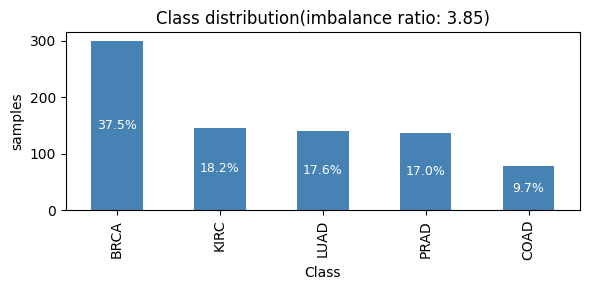

In [4]:
counts = y.value_counts()
props = y.value_counts(normalize=True) * 100
imbalance_ratio =  counts.max() / counts.min()


fig, ax = plt.subplots(figsize=(6, 3))
bars = counts.plot.bar(ax=ax, color="steelblue")
ax.set_ylabel("samples")
ax.set_title(f"Class distribution(imbalance ratio: {imbalance_ratio:.2f})")

for bar, pct in zip(bars.patches, props):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, f"{pct:.1f}%",
            ha="center", va="center", color="white", fontsize=9)

plt.tight_layout()
plt.show()

## 2. Missing values, constant & near-zero-variance genes

Constant genes carry zero signal and can break some scalers (division by zero). Near-zero-variance genes rarely help linear or shallow models on 801 samples — flag them so we can drop before training.

Total NaN cells: 0
Constant genes (std == 0):            0 / 20264
Near-zero-variance (std < 1e-4):      0 / 20264


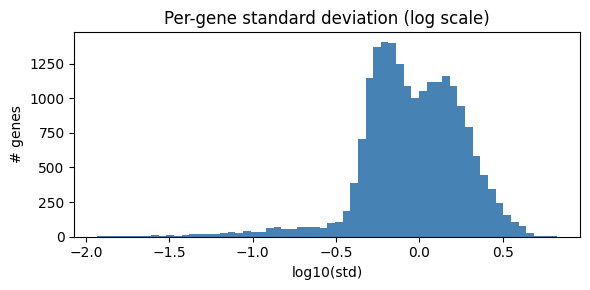

In [5]:
n_nan = X.isna().sum().sum()
print(f"Total NaN cells: {n_nan}")

gene_std = X.std(axis=0)
n_constant = int((gene_std == 0).sum())
n_near_zero = int((gene_std < 1e-4).sum())
print(f"Constant genes (std == 0):        {n_constant:5d} / {X.shape[1]}")
print(f"Near-zero-variance (std < 1e-4):  {n_near_zero:5d} / {X.shape[1]}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(np.log10(gene_std.replace(0, np.nan).dropna()), bins=60, color="steelblue")
ax.set_xlabel("log10(std)")
ax.set_ylabel("# genes")
ax.set_title("Per-gene standard deviation (log scale)")
plt.tight_layout()
plt.show()

### Prune constant genes

Drop the 267 genes with `std == 0` and persist the pruned matrix to `data_pruned.csv` next to the raw `data.csv`. The raw file stays untouched so downstream code can opt in.

In [55]:
constant_mask = X.std(axis=0) == 0
kept_genes = X.columns[~constant_mask]
X_pruned = X.loc[:, kept_genes]

out_path = DATA_DIR / "data_pruned.csv"
X_pruned.to_csv(out_path)

print(f"Dropped {int(constant_mask.sum())} constant genes")
print(f"Pruned shape: {X_pruned.shape}   (was {X.shape})")
print(f"Wrote: {out_path.resolve()}")

Dropped 267 constant genes
Pruned shape: (801, 20264)   (was (801, 20531))
Wrote: /home/msul/Documents/web/MCS_26/FLS/federated_learning_system/gene+expression+cancer+rna+seq/TCGA-PANCAN-HiSeq-801x20531/data_pruned.csv


## 3. Distributional sanity check

Fingerprint for raw vs. processed:

| Signal | Raw HTSeq counts | Log2 / RSEM-normalized |
|---|---|---|
| dtype | integer | float |
| range | 0 to 10^5+, very skewed | ~0 to ~20, roughly bell-shaped |
| negatives | never | never (log2(x+1)) or sometimes (z-scored) |

UCI's copy is documented as **already gene-level RSEM/log2-transformed** — verify rather than assume.

In [5]:
vals = X.values

print(f"dtype:   {X.dtypes.iloc[0]}")
print(f"min:     {vals.min():.4f}")
print(f"max:     {vals.max():.4f}")
print(f"mean:    {vals.mean():.4f}")
print(f"std:     {vals.std():.4f}")
print(f"% zeros: {(vals == 0).mean() * 100:.2f}%")
print(f"any neg: {bool((vals < 0).any())}")

is_int = np.array_equal(vals, vals.astype(int))
print(f"\nAll values integer-valued? {is_int}")
print("→ float dtype + max in single digits/teens + no negatives")
print("  ==> data is ALREADY log-transformed RSEM (not raw counts).")

dtype:   float64
min:     0.0000
max:     20.7788
mean:    6.4433
std:     4.0582
% zeros: 14.22%
any neg: False

All values integer-valued? False
→ float dtype + max in single digits/teens + no negatives
  ==> data is ALREADY log-transformed RSEM (not raw counts).


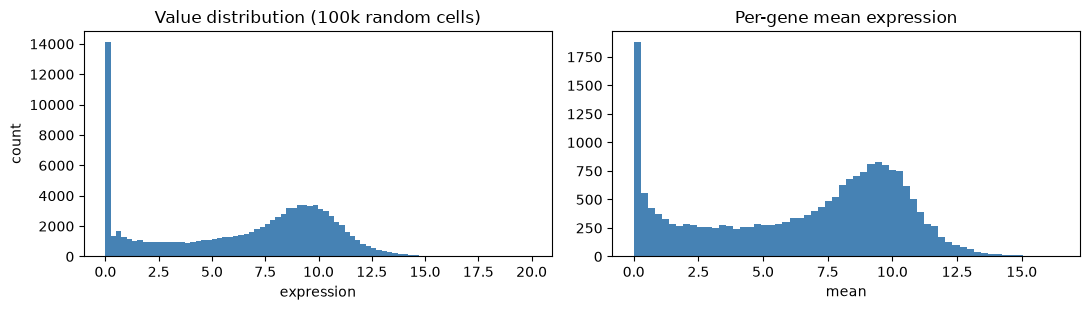

In [6]:
rng = np.random.default_rng(RANDOM_STATE)
sample_vals = rng.choice(vals.ravel(), size=100_000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].hist(sample_vals, bins=80, color="steelblue")
axes[0].set_title("Value distribution (100k random cells)")
axes[0].set_xlabel("expression")
axes[0].set_ylabel("count")
axes[1].hist(X.mean(axis=0), bins=60, color="steelblue")
axes[1].set_title("Per-gene mean expression")
axes[1].set_xlabel("mean")
plt.tight_layout()
plt.show()

## 4. Duplicate / near-duplicate samples

Exact duplicates are rare in RNA-seq but possible if the same aliquot was submitted twice. Near-duplicates (e.g. cosine ≥ 0.9999) usually indicate the same patient sequenced on two runs — those must not be split across train/test *or* across federated clients.

In [34]:
print(X.shape)

(801, 20531)


In [54]:
from sklearn.metrics.pairwise import cosine_similarity

n_exact_dup = int(X.duplicated().sum())
print(f"Exact duplicate sample rows: {n_exact_dup}")

sim = cosine_similarity(X.values)
np.fill_diagonal(sim, 0.0)

i_upper, j_upper = np.triu_indices_from(sim, k=1)
pair_sims = sim[i_upper, j_upper]

for thr in (0.9999, 0.999, 0.99, 0.98):
    n_pairs = int((pair_sims >= thr).sum())
    print(f"Pairs with cosine similarity >= {thr}: {n_pairs}")

top_k = 20
mask = (pair_sims > 0.978) & (pair_sims <= 0.99)
range_idx = np.where(mask)[0]

sorted_range_idx = range_idx[np.argsort(pair_sims[range_idx])[::-1]]
top_idx = sorted_range_idx[:top_k]


# top_idx = np.argsort(pair_sims)[::-1][:top_k]
top_pairs = pd.DataFrame({
    "sample_a": X.index[i_upper[top_idx]],
    "sample_b": X.index[j_upper[top_idx]],
    "class_a":  y.iloc[i_upper[top_idx]].values,
    "class_b":  y.iloc[j_upper[top_idx]].values,
    "cosine":   pair_sims[top_idx].round(6),
})
print(f"\n{len(range_idx)} pairs found in [0.96, 0.97]; showing top {len(top_pairs)}:")
print(top_pairs.to_string(index=False))



class_a_range = y.iloc[i_upper[range_idx]].values
class_b_range = y.iloc[j_upper[range_idx]].values

n_same_class = int((class_a_range == class_b_range).sum())
n_diff_class = int((class_a_range != class_b_range).sum())

classes_in_range = np.concatenate([class_a_range, class_b_range])

class_counts = pd.Series(classes_in_range).value_counts(ascending=False)
class_pct = pd.Series(classes_in_range).value_counts(normalize=True, ascending=False) * 100

print(f"Pairs in [0.96, 0.97]: {len(range_idx)}")
print(f"Same class:      {n_same_class} ({n_same_class / len(range_idx) * 100:.1f}%)")
print(f"Different class: {n_diff_class} ({n_diff_class / len(range_idx) * 100:.1f}%)")


print(f"Pairs in [0.96, 0.97]: {len(range_idx)} ({len(classes_in_range)} class-appearances)\n")
print(pd.DataFrame({"count": class_counts, "pct": class_pct.round(1)}))

Exact duplicate sample rows: 0
Pairs with cosine similarity >= 0.9999: 0
Pairs with cosine similarity >= 0.999: 0
Pairs with cosine similarity >= 0.99: 4788
Pairs with cosine similarity >= 0.98: 46799

53485 pairs found in [0.96, 0.97]; showing top 20:
  sample_a   sample_b class_a class_b   cosine
sample_480 sample_657    PRAD    PRAD 0.990000
 sample_62 sample_452    BRCA    BRCA 0.990000
sample_452 sample_459    BRCA    BRCA 0.990000
sample_715 sample_752    PRAD    PRAD 0.990000
sample_370 sample_605    BRCA    BRCA 0.989999
 sample_15 sample_333    BRCA    BRCA 0.989999
 sample_18 sample_170    KIRC    KIRC 0.989998
 sample_84 sample_124    PRAD    PRAD 0.989998
 sample_65 sample_321    COAD    COAD 0.989998
sample_113 sample_496    PRAD    PRAD 0.989997
 sample_19 sample_124    PRAD    PRAD 0.989996
sample_124 sample_587    PRAD    PRAD 0.989996
sample_656 sample_661    PRAD    PRAD 0.989996
sample_227 sample_731    PRAD    PRAD 0.989996
sample_468 sample_643    KIRC    KIRC 0.98

In [53]:
avg_intraclass_sim = {}
for cls in y.unique():
    idx = np.where(y.values == cls)[0]
    if len(idx) < 2:
        continue
    sub_sim = sim[np.ix_(idx, idx)]
    iu, ju = np.triu_indices_from(sub_sim, k=1)
    avg_intraclass_sim[cls] = sub_sim[iu, ju].mean()

pd.Series(avg_intraclass_sim).sort_values(ascending=False)

PRAD    0.986133
KIRC    0.983840
COAD    0.983123
LUAD    0.978632
BRCA    0.978615
dtype: float64

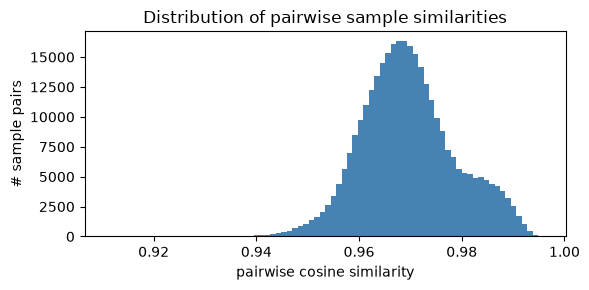

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(pair_sims, bins=80, color="steelblue")
ax.set_xlabel("pairwise cosine similarity")
ax.set_ylabel("# sample pairs")
ax.set_title("Distribution of pairwise sample similarities")
plt.tight_layout()
plt.show()

## Summary of findings

_Fill in after running the cells above — these become the rationale for choices in [dataset.py](../fl_rnaseq/dataset.py)._

- **Class balance:** … (imbalance ratio, whether to stratify + use macro-F1)
- **Missing / constant genes:** … (count of NaNs, count of constant / near-zero-variance genes to drop)
- **Distribution:** … (confirmed log-transformed? need z-score / StandardScaler?)
- **Duplicates:** … (exact dupes, near-dupes above threshold, action taken)